In this Notebook we run a test for all non-equivalent resolution-3 rules.

We run each rule for ...
- Three different networks: lattice, small-world, random of 900 nodes
- 900 initial configurations (for lattice), or 30 initial configurations on 30 networks (for non-lattice)
- 900 minimal perturbations
- 100 time steps (which arguably is too few)

For each of the 36 rules, we therefore get 900 configuration evolutions and 900 damage evolutions.
- That's a total of 2 * (# rules) * (# nodes) * (# samples) * (# networks) * (# time steps) = 2 * 36 * 900 * 900 * 3 * 100 = 17.5 billion Booleans. This is at the very least 2 GB (uncompressed)
- We want to save this raw data in a systematic fashion
- We are eventually only interested in the average over all nodes (average state and average defect).
- From these network averages, we take the final $\Delta t$ time steps of every sample.
- Then we take the median and the interquartile range (IQR) over these time steps and over the ensemble of 900 samples.
- We end up with a single value and its IQR for the state average $\bar{\rho}^T$ and the defect average $\bar{\delta}^T$, per rule, per network.
- We want to make three plots (one per network) of the final state average vs. the final defect average. Because we want to show that, just like the HW and the BS, these values are correlated.

# Load packages

In [112]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# compact saving of data
import h5py

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule, get_nonequiv_rules
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.analysis import median_and_percentiles_over_ensemble

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create networks

In [166]:
# PARAMETERS
#####################################################################################################################
L = 30                              # Grid size (L x L) WATCH OUT with values, becomes computationally expensive fast
num_nodes = L**2
rewiring_prob = 0.2                 # Rewiring probability for the small-world network
degree = 8                          # degree for lattice model (Moore neighbourhood)
num_edges = num_nodes * degree // 2 # number of undirected edges
num_graphs_per_type = 30
num_init_conf_per_graph = 30
init_dens = 0.5
T = 100
delta_t = 10
#####################################################################################################################

graph_names = ["Toroidal Lattice", f"Small World", "Random"]

# Create toroidal lattice
lattice_graph = create_2d_torus_lattice(L, degree=degree)
lattice_graphs = [lattice_graph]*num_graphs_per_type

# create small_world graphs. These are connected (see definition)
small_world_graphs = [watts_strogatz_rewire(lattice_graph, rewiring_prob) for _ in range(num_graphs_per_type)]

# create connected random graphs
random_graphs = []
for _ in range(num_graphs_per_type):
    while True:
        random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, m=num_edges)
        if random_graph.is_connected():
            random_graphs.append(random_graph)
            break

# find edges
lattice_edges = []
for lattice_graph in lattice_graphs:
    lattice_graph.to_directed()
    lattice_edge = tc.tensor(lattice_graph.get_edgelist()).T
    lattice_edges.append(lattice_edge)
    lattice_graph.to_undirected()

small_world_edges = []
for small_world_graph in small_world_graphs:
    small_world_graph.to_directed()
    small_world_edge = tc.tensor(small_world_graph.get_edgelist()).T
    small_world_edges.append(small_world_edge)
    small_world_graph.to_undirected()

random_edges = []
for random_graph in random_graphs:
    random_graph.to_directed()
    random_edge = tc.tensor(random_graph.get_edgelist()).T
    random_edges.append(random_edge)
    random_graph.to_undirected()

graphs_per_type = [lattice_graphs, small_world_graphs, random_graphs]
edges_per_type = [lattice_edges, small_world_edges, random_edges]

# Run over all non-equivalent rules and create configuration evolutions

In [163]:
resolution = 3
beta_sigma_list = get_nonequiv_rules(resolution)

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

# open new lists. These will have dimensions [types][rules]
state_medians_per_type = []
state_Q1_per_type = []
state_Q3_per_type = []
defect_medians_per_type = []
defect_Q1_per_type = []
defect_Q3_per_type = []
# loop over graph types
for edges, graph_name in zip(edges_per_type, graph_names):
    print(f"Working on {graph_name} network. Now running through the non-equivalent rules ...")
    # open new lists
    state_medians_per_rule = []
    state_Q1_per_rule = []
    state_Q3_per_rule = []
    defect_medians_per_rule = []
    defect_Q1_per_rule = []
    defect_Q3_per_rule = []
    # loop over rules
    for beta, sigma in tqdm(beta_sigma_list, total=len(beta_sigma_list)):
        # initialise model
        B_set = binary_indices(beta)
        S_set = binary_indices(sigma)
        model = LLNA(resolution, B_set, S_set, iso=True)
        # get initial configurations
        init_configs_array = init_config_with_dens(num_nodes*num_init_conf_per_graph*num_graphs_per_type, init_dens)
        init_configs_array = init_configs_array.reshape(num_graphs_per_type, num_init_conf_per_graph, num_nodes)
        # get initial defects
        init_defects_array = np.eye(num_nodes, dtype=int)[np.random.choice(num_nodes, num_init_conf_per_graph*num_graphs_per_type, replace=False)]
        init_defects_array = init_defects_array.reshape(num_graphs_per_type, num_init_conf_per_graph, num_nodes)
        # find defected initial configurations
        init_configs_with_defect_array = (init_configs_array + init_defects_array) % 2
        # open new arrays that will collect all time series
        state_averages_stack = np.empty((0,T+1))
        defect_averages_stack = np.empty((0,T+1))
        # loop over graphs
        for edge, init_configs, init_configs_with_defect in zip(edges, init_configs_array, init_configs_with_defect_array):
            # evolve the configuration
            configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)
            configs_with_defect = model.forward(edge, tc.tensor(init_configs_with_defect), T=T).numpy().astype(int)
            defects = (configs + configs_with_defect) % 2
            # get the average over all nodes
            state_averages = np.mean(configs, axis=2)
            defect_averages = np.mean(defects, axis=2)
            # add these to the stack
            state_averages_stack = np.vstack((state_averages_stack, state_averages))
            defect_averages_stack = np.vstack((defect_averages_stack, defect_averages))
        # get the median and IQR for the ensemble
        state_median, state_Q1, state_Q3 = median_and_percentiles_over_ensemble(state_averages_stack, delta_t=delta_t)
        defect_median, defect_Q1, defect_Q3 = median_and_percentiles_over_ensemble(defect_averages_stack, delta_t=delta_t)
        # append to lists
        state_medians_per_rule.append(state_median)
        state_Q1_per_rule.append(state_Q1)
        state_Q3_per_rule.append(state_Q3)
        defect_medians_per_rule.append(defect_median)
        defect_Q1_per_rule.append(defect_Q1)
        defect_Q3_per_rule.append(defect_Q3)
    # append to lists
    state_medians_per_type.append(state_medians_per_rule)
    state_Q1_per_type.append(state_Q1_per_rule)
    state_Q3_per_type.append(state_Q3_per_rule)
    defect_medians_per_type.append(defect_medians_per_rule)
    defect_Q1_per_type.append(defect_Q1_per_rule)
    defect_Q3_per_type.append(defect_Q3_per_rule)

# turn lists into numpy arrays
state_medians_per_type = np.array(state_medians_per_type)
state_Q1_per_type = np.array(state_Q1_per_type)
state_Q3_per_type = np.array(state_Q3_per_type)
defect_medians_per_type = np.array(defect_medians_per_type)
defect_Q1_per_type = np.array(defect_Q1_per_type)
defect_Q3_per_type = np.array(defect_Q3_per_type)

Working on Lattice network. Now running through the non-equivalent rules ...


100%|██████████| 36/36 [17:06<00:00, 28.51s/it]


Working on Small World network. Now running through the non-equivalent rules ...


100%|██████████| 36/36 [17:54<00:00, 29.85s/it]


Working on Random network. Now running through the non-equivalent rules ...


100%|██████████| 36/36 [17:04<00:00, 28.45s/it]


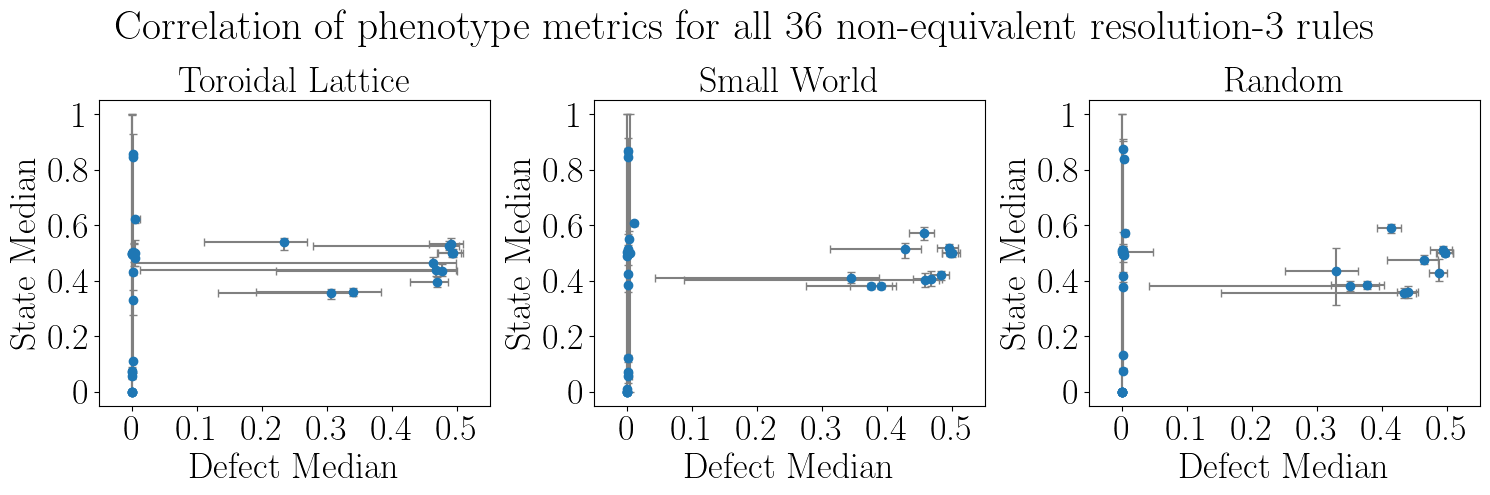

In [ ]:
fig, axs = plt.subplots(1,3,figsize=(15,5))
fontsize=26

for idx, ax in enumerate(axs):
    graph_name = graph_names[idx]
    state_medians = state_medians_per_type[idx]
    state_err = [state_medians - state_Q1_per_type[idx], state_Q3_per_type[idx] - state_medians]
    defect_medians = defect_medians_per_type[idx]
    defect_err = [defect_medians - defect_Q1_per_type[idx], defect_Q3_per_type[idx] - defect_medians]

    # Create scatter plot with uncertainty crosses
    ax.errorbar(defect_medians, state_medians, xerr=defect_err, yerr=state_err, fmt='o', ecolor='gray', capsize=3)

    # make nice labels
    ax.set_xlabel('Defect Median', fontsize=fontsize)
    ax.set_ylabel('State Median', fontsize=fontsize)
    ax.set_title(graph_name, fontsize=fontsize)

    # get identical limits for each plot
    ax.set_xlim([-0.05,.55])
    ax.set_ylim([-0.05, 1.05])
    xticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=fontsize)
    yticks = [0, .2, .4, .6, .8, 1]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=fontsize)

fig.suptitle(f"Correlation of phenotype metrics for all $36$ non-equivalent resolution-$3$ rules", fontsize=fontsize+4)
fig.tight_layout()

savename = f"state-median-vs-defect-median_resolution3.pdf"
# plt.savefig(savename, bbox_inches='tight')

# Save files

In [175]:
# Saving to HDF5

graph_names_h5 = ['toroidal-lattice', 'small-world', 'network']

with h5py.File('state-median-vs-defect-median.h5', 'w') as f:
    for idx, graph_name_h5 in enumerate(graph_names_h5):
        f.create_dataset(f'resolution3/{graph_name_h5}/state/median', data=state_medians_per_type[idx], compression='gzip')
        f.create_dataset(f'resolution3/{graph_name_h5}/state/q1', data=state_Q1_per_type[idx], compression='gzip')
        f.create_dataset(f'resolution3/{graph_name_h5}/state/q3', data=state_Q3_per_type[idx], compression='gzip')
        f.create_dataset(f'resolution3/{graph_name_h5}/defect/median', data=defect_medians_per_type[idx], compression='gzip')
        f.create_dataset(f'resolution3/{graph_name_h5}/defect/q1', data=defect_Q1_per_type[idx], compression='gzip')
        f.create_dataset(f'resolution3/{graph_name_h5}/defect/q3', data=defect_Q1_per_type[idx], compression='gzip')

    # You can even attach metadata
    f['resolution3'].attrs['num_nodes'] = f'{L}x{L}'
    f['resolution3'].attrs['rewiring_prob'] = f'{rewiring_prob}'
    f['resolution3'].attrs['num_graphs_per_type'] = f'{num_graphs_per_type}'
    f['resolution3'].attrs['num_init_conf_per_graph'] = f'{num_init_conf_per_graph}'
    f['resolution3'].attrs['init_dens'] = f'{init_dens}'
    f['resolution3'].attrs['T'] = f'{T}'
    f['resolution3'].attrs['delta_t'] = f'{delta_t}'
